In [ ]:
from torch.distributions.binomial import Binomial
import torch
import autorootcwd
import matplotlib.pyplot as plt

prior = 'data/OCTA500_6M/FRUnet/train/batch_0_image.jpg'
prior = plt.imread(prior)
prior = torch.tensor(prior) / 255.0
print(prior.min(), prior.max())
gaussian_noise = torch.randn_like(prior)
bernoulli_sample = Binomial(1, prior).sample()
poisson_sample = torch.randn_like(prior)

fig, axes = plt.subplots(1, 4, figsize=(24, 6))

axes[0].imshow(prior.squeeze(), cmap='gray')
axes[0].set_title('Prior Output')
axes[0].axis('off')

axes[1].imshow(gaussian_noise.squeeze(), cmap='gray')
axes[1].set_title('Gaussian Noise')
axes[1].axis('off')

axes[2].imshow(bernoulli_sample.squeeze(), cmap='gray')
axes[2].set_title('Bernoulli Sample')
axes[2].axis('off')

axes[3].imshow(poisson_sample.squeeze(), cmap='gray')
axes[3].set_title('Poisson Sample')
axes[3].axis('off')

plt.tight_layout()
plt.show()

# Sampling methods

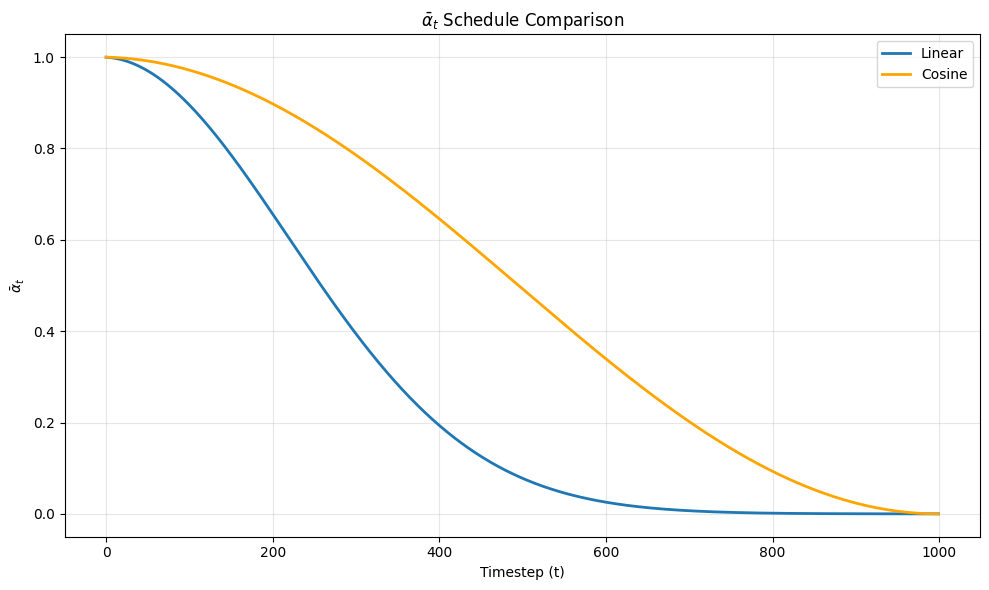

In [2]:
import numpy as np
import math
import matplotlib.pyplot as plt


def betas_for_alpha_bar(num_diffusion_timesteps, alpha_bar, max_beta=0.999):
    """
    alpha_t_bar 함수(t=[0,1] 범위에서 (1-beta)의 누적 곱)를 기반으로
    beta 스케줄을 생성합니다.
    """
    betas = []
    for i in range(num_diffusion_timesteps):
        t1 = i / num_diffusion_timesteps
        t2 = (i + 1) / num_diffusion_timesteps
        # beta_t = 1 - (alpha_bar_t / alpha_bar_{t-1})
        betas.append(min(1 - alpha_bar(t2) / alpha_bar(t1), max_beta))
    return np.array(betas)


def linear_noise_schedule(num_diffusion_timesteps):
    # T가 1000이 아닐 경우를 대비해 스케일링 적용
    scale = 1000 / num_diffusion_timesteps
    beta_start = scale * 0.0001
    beta_end = scale * 0.02
    return np.linspace(
        beta_start, beta_end, num_diffusion_timesteps, dtype=np.float64
    )


def cosine_noise_schedule(num_diffusion_timesteps):
    """
    Improved DDPM에서 제안한 Cosine Schedule
    s = 0.008 (offset)
    """
    return betas_for_alpha_bar(
        num_diffusion_timesteps,
        lambda t: math.cos((t + 0.008) / 1.008 * math.pi / 2) ** 2,
    )


def _extract_into_tensor(arr, timesteps, broadcast_shape):
    """
    Extract values from a 1-D numpy array for a batch of indices.

    :param arr: the 1-D numpy array.
    :param timesteps: a tensor of indices into the array to extract.
    :param broadcast_shape: a larger shape of K dimensions with the batch
                            dimension equal to the length of timesteps.
    :return: a tensor of shape [batch_size, 1, ...] where the shape has K dims.
    """
    res = torch.from_numpy(arr).to(device=timesteps.device)[timesteps].float()
    while len(res.shape) < len(broadcast_shape):
        res = res[..., None]
    return res.expand(broadcast_shape)


# --- 실행 및 시각화 ---
num_diffusion_timesteps = 1000

betas_linear = linear_noise_schedule(num_diffusion_timesteps)
betas_cosine = cosine_noise_schedule(num_diffusion_timesteps)

# alpha_bar 계산: cumulative product of (1 - beta)
alphas_linear = 1 - betas_linear
alphas_cosine = 1 - betas_cosine
alpha_bar_linear = np.cumprod(alphas_linear)
alpha_bar_cosine = np.cumprod(alphas_cosine)

plt.figure(figsize=(10, 6))
plt.plot(alpha_bar_linear, label='Linear', linewidth=2)
plt.plot(alpha_bar_cosine, label='Cosine', linewidth=2, color='orange')
plt.title(r'$\bar{\alpha}_t$ Schedule Comparison')
plt.ylabel(r'$\bar{\alpha}_t$')
plt.xlabel('Timestep (t)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Binomial

## w/o prior

tensor(0.) tensor(1.)


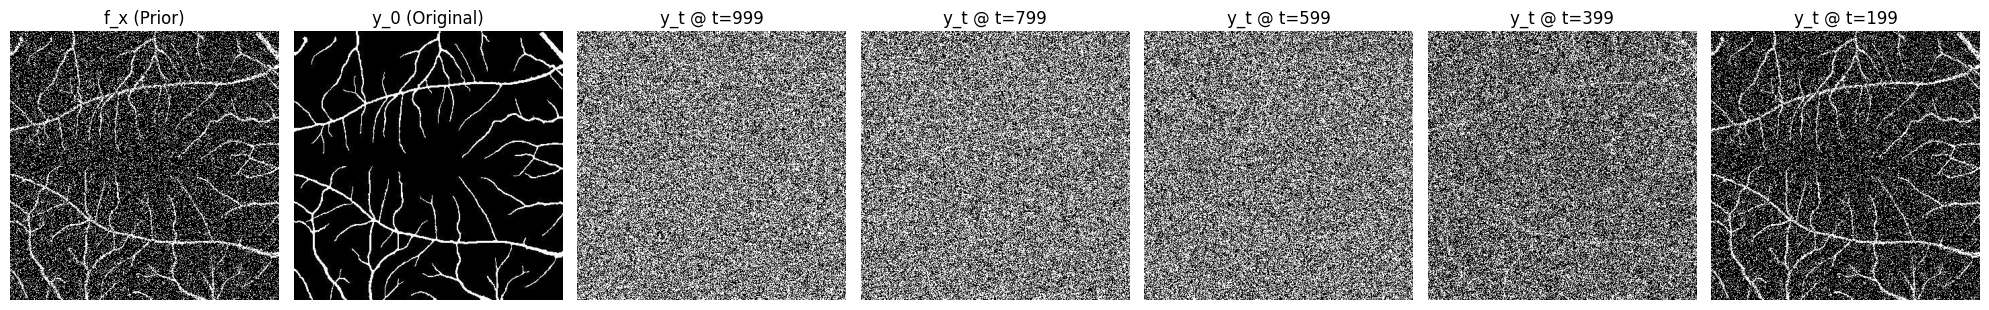

In [3]:
import autorootcwd
import torch
import matplotlib.pyplot as plt
import math
from torch.distributions.binomial import Binomial


y_0 = 'data/OCTA500_6M/FRUnet/train/batch_0_mask.jpg'
y_0 = plt.imread(y_0)
y_0 = torch.tensor(y_0) / 255.0
print(y_0.min(), y_0.max())

'''
q(y_t|y_0, f(x)) = Binomial(n=1, 1/2)
'''
num_diffusion_timesteps = 1000
y_t_arrs = []
y_T = torch.ones_like(y_0) * 0.5  # 초기 y_T (모든 픽셀 0.5)
betas = linear_noise_schedule(num_diffusion_timesteps)
betas = np.array(betas, dtype=np.float64)
alphas = 1.0-betas
alphas_cumprod = np.cumprod(alphas, axis=0)
for t in range(num_diffusion_timesteps-1, -1, -200):
    timestep = torch.tensor([t] * y_T.shape[0])
    t_idx = t-1 if t > 0 else 0
    mean = _extract_into_tensor(alphas_cumprod, timestep, y_0.shape) * y_0 \
        + (1 - _extract_into_tensor(alphas_cumprod, timestep, y_0.shape)) / 2
    bernoulli_dist = Binomial(1, mean)
    y_t = bernoulli_dist.sample()
    y_t_arrs.append((t, y_t.numpy()))

fig, axes = plt.subplots(1, len(y_t_arrs) + 2, figsize=(20, 5))

# f_x 표시
axes[0].imshow(y_t.squeeze(), cmap='gray')
axes[0].set_title('f_x (Prior)')
axes[0].axis('off')

# y_0 표시
axes[1].imshow(y_0.squeeze(), cmap='gray')
axes[1].set_title('y_0 (Original)')
axes[1].axis('off')

# y_t 시리즈 표시
for i, (y_t_tuple) in enumerate(y_t_arrs):
    t, y_t = y_t_tuple
    axes[i + 2].imshow(y_t.squeeze(), cmap='gray')
    axes[i + 2].set_title(f'y_t @ t={t}')
    axes[i + 2].axis('off')

plt.tight_layout()
plt.show()

## w/ prior

In [ ]:
import autorootcwd
import torch
import matplotlib.pyplot as plt
import math
from torch.distributions.binomial import Binomial


f_x = 'data/OCTA500_6M/FRUnet/train/batch_0_image.jpg'
f_x = plt.imread(f_x)
f_x = torch.tensor(f_x) / 255.0

y_0 = 'data/OCTA500_6M/FRUnet/train/batch_0_mask.jpg'
y_0 = plt.imread(y_0)
y_0 = torch.tensor(y_0) / 255.0
print(f_x.min(), f_x.max(), y_0.min(), y_0.max())

'''
q(y_t|y_0, f(x)) = Binomial(n=1, p=f(x) * alpha_t + y_0 * (1 - alpha_t))
'''

y_t_arrs = []
y_t_with_mask_arrs = []
for t in range(num_diffusion_timesteps, -1, -200):
    t_idx = t-1 if t > 0 else 0
    alpha_t = cosine_noise_schedule(num_diffusion_timesteps)[t_idx]
    print(f'alpha_t @ t={t}: {alpha_t}')
    bernoulli_dist = Binomial(1, f_x * alpha_t + y_0 * (1 - alpha_t))
    y_t = bernoulli_dist.sample()
    mask = (y_t > 0).float()
    y_t_with_mask = y_t * mask
    y_t_arrs.append((t, y_t.numpy()))
    y_t_with_mask_arrs.append((t, y_t_with_mask.numpy()))

fig, axes = plt.subplots(1, len(y_t_arrs) + 2, figsize=(20, 5))

# f_x 표시
axes[0].imshow(f_x.squeeze(), cmap='gray')
axes[0].set_title('f_x (Prior)')
axes[0].axis('off')

# y_0 표시
axes[1].imshow(y_0.squeeze(), cmap='gray')
axes[1].set_title('y_0 (Original)')
axes[1].axis('off')

# y_t 시리즈 표시
for i, (y_t_tuple, y_t_with_mask_tuple) in enumerate(zip(y_t_arrs, y_t_with_mask_arrs)):
    t, y_t = y_t_tuple
    t_2, y_t_with_mask = y_t_with_mask_tuple
    assert t == t_2, "Timestep mismatch between y_t and y_t_with_mask"
    axes[i + 2].imshow(y_t.squeeze(), cmap='gray')
    axes[i + 2].set_title(f'y_t @ t={t}')
    axes[i + 2].axis('off')
    print(np.sum(y_t != y_t_with_mask))

plt.tight_layout()
plt.show()

In [ ]:
import autorootcwd
import torch
import matplotlib.pyplot as plt
import math
from torch.distributions.poisson import Poisson

num_diffusion_timesteps = 1000
f_x = 'data/OCTA500_6M/FRUnet/train/batch_0_image.jpg'
f_x = plt.imread(f_x)
f_x = torch.tensor(f_x) / 255.0

y_0 = 'data/OCTA500_6M/FRUnet/train/batch_0_mask.jpg'
y_0 = plt.imread(y_0)
y_0 = torch.tensor(y_0) / 255.0
print(f_x.min(), f_x.max(), y_0.min(), y_0.max())

binomial_dist = Binomial(1, f_x)
binomial_sample = binomial_dist.sample()
plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1)
plt.imshow(binomial_sample.squeeze(), cmap='gray')
plt.title('Sample from Binomial(1, f_x)')
plt.axis('off')

plt.subplot(1, 3, 2)
noise = binomial_sample - f_x
plt.imshow(noise.squeeze(), cmap='gray')
plt.title('Noise (Binomial Sample - f_x)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.hist(binomial_sample.flatten().numpy(), bins=50, edgecolor='black')
plt.title('Binomial Distribution Histogram')
plt.xlabel('Value')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

## Poisson

In [ ]:
import autorootcwd
import torch
import matplotlib.pyplot as plt
from torch.distributions.poisson import Poisson

f_x = 'data/OCTA500_6M/FRUnet/train/batch_0_image.jpg'
f_x = plt.imread(f_x)
f_x = torch.tensor(f_x) / 255.0

y_0 = 'data/OCTA500_6M/FRUnet/train/batch_0_mask.jpg'
y_0 = plt.imread(y_0)
y_0 = torch.tensor(y_0) / 255.0

f_x = f_x + 1e-8

poisson_dist = Poisson(rate=f_x, validate_args=False)
k = torch.zeros_like(y_0)
log_prob_0 = poisson_dist.log_prob(k)
prob_0 = torch.exp(log_prob_0)

k = torch.ones_like(y_0)
log_prob_1 = poisson_dist.log_prob(k)
prob_1 = torch.exp(log_prob_1)

prob = prob_0 | prob_1

print(f"Prob min/max: {prob.min().item():.4f}, {prob.max().item():.4f}")

plt.figure(figsize=(20, 5))
plt.suptitle('Poisson Sampling Results (Continuous Approximation)', fontsize=16)

plt.subplot(1, 4, 1)
plt.imshow(f_x.squeeze(), cmap='gray')
plt.title('Input Rate (f_x)')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(prob.squeeze(), cmap='gray', vmin=0, vmax=1)
plt.title('Probability P(y_0 | f_x)')
plt.axis('off')

plt.subplot(1, 4, 3)
diff_map = prob - f_x
plt.imshow(diff_map.squeeze(), cmap='gray')
plt.title('Difference (Prob - f_x)')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.hist(prob.flatten().numpy(), bins=50, edgecolor='black')
plt.title('Probability Histogram')
plt.xlabel('Probability')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [ ]:
import autorootcwd
import torch
import matplotlib.pyplot as plt
import math
from torch.distributions.poisson import Poisson

num_diffusion_timesteps = 1000
f_x = 'data/OCTA500_6M/FRUnet/train/batch_0_image.jpg'
f_x = plt.imread(f_x)
f_x = torch.tensor(f_x) / 255.0

y_0 = 'data/OCTA500_6M/FRUnet/train/batch_0_mask.jpg'
y_0 = plt.imread(y_0)
y_0 = torch.tensor(y_0) / 255.0
print(f_x.min(), f_x.max(), y_0.min(), y_0.max())


y_t_arrs = []
mask_arrs = []
for t in range(num_diffusion_timesteps, -1, -200):
    t_idx = t-1 if t > 0 else 0
    alpha_t = cosine_noise_schedule(num_diffusion_timesteps)[t_idx]
    _lambda = f_x
    k = 1
    prob = torch.exp(-_lambda) * (_lambda**k) / math.factorial(k)
    y_t = (f_x * prob) * alpha_t + y_0 * (1 - alpha_t)
    mask = prob

    y_t_arrs.append((t, y_t.numpy()))
    mask_arrs.append((t, mask.numpy()))

fig, axes = plt.subplots(2, len(y_t_arrs) + 2, figsize=(20, 5))

# f_x 표시
axes[0, 0].imshow(f_x.squeeze(), cmap='gray')
axes[0, 0].set_title('f_x (Prior)')
axes[0, 0].axis('off')

# y_0 표시
axes[0, 1].imshow(y_0.squeeze(), cmap='gray')
axes[0, 1].set_title('y_0 (Original)')
axes[0, 1].axis('off')

axes[1, 0].axis('off')
axes[1, 1].axis('off')


# y_t 시리즈 표시
for i, (y_t_tuple, mask_tuple) in enumerate(zip(y_t_arrs, mask_arrs)):
    t_1, y_t = y_t_tuple
    t_2, mask = mask_tuple
    assert t_1 == t_2, "Timestep mismatch between y_t and mask"
    t = t_1
    noise_idx = t-1 if t > 0 else 0
    axes[0, i + 2].imshow(y_t.squeeze(), cmap='gray')
    axes[0, i + 2].set_title(f'y_t @ t={t}')
    axes[0, i + 2].axis('off')
    axes[1, i + 2].imshow(mask.squeeze(), cmap='gray')
    axes[1, i + 2].set_title(f'$alpha_t$: {cosine_noise_schedule(num_diffusion_timesteps)[noise_idx]:.6f}\nmask @ t={t}')
    axes[1, i + 2].axis('off')

plt.tight_layout()
plt.show()

# Results(Grid)

In [ ]:
import os
import matplotlib.pyplot as plt
import autorootcwd
from natsort import natsorted

# Load intermediate step images
sampling_method = 'bernoulli'
dataset = 'OCTA500_3M'
model = 'FRUnet'
epoch = 50000
result_path = f"workdir/{sampling_method}/{dataset}-{model}/results-{epoch:06d}/intermediates"

# Get all step images for the first image (0_image_0_step_*.png)
step_files = [f for f in os.listdir(result_path) if f.startswith('0_image_0_step_')]
step_files = natsorted(step_files)
index = list(range(1000, -51, -50))
# print("Intermediate step files:", step_files)

print(f"Found {len(step_files)} intermediate steps")

# Create 5x4 grid plot
fig, axes = plt.subplots(5, 5, figsize=(16, 16))
axes = axes.flatten()

for i, step_file in enumerate(step_files[1:]):

    img_path = os.path.join(result_path, step_file)
    img = plt.imread(img_path)

    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f'Step {index[i]}')
    axes[i].axis('off')

# Hide any unused subplots
for ax in axes[len(step_files)-1:]:
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Create 2x6 grid and plot every-other step; hide the final unused subplot
fig, axes = plt.subplots(2, 5, figsize=(24, 8))
axes = axes.flatten()

step_list = step_files[::2]
print(len(step_list))
for i, step_file in enumerate(step_list):
    print(f'Loading step file: {step_file}')
    img_path = os.path.join(result_path, step_file)
    img = plt.imread(img_path)
    axes[i].imshow(img, cmap='gray')
    axes[i].axis('off')

# Hide any remaining (unused) subplots, including the last one
for ax in axes[len(step_list):]:
    ax.axis('off')

plt.tight_layout()
plt.show()